In [1]:
import numpy as np
import pandas as pd
import utils
import pickle

from matplotlib import pyplot as plt
from scipy.stats import loguniform, uniform, randint
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

In [2]:
with open(f'data/dataset_clean.pkl', 'rb') as file:
    X_train, X_val, X_test, y_train, y_val, y_test = pickle.load(file)['retval']

In [3]:
# Create a tuning subset
X_tune, _, y_tune, _ = train_test_split(X_train, y_train, train_size=100000, random_state=42)

# Initialize the base model
rf_base = RandomForestRegressor(max_features='sqrt', random_state=42)

# Define the hyperparameter search space
rf_param_grid = {
    'max_depth': [10, 15, 20, 25, 30], #randint(10, 30)
    'n_estimators': [100, 200, 250, 300], #randint(100, 400)
    'max_features': [1, 2, 3, 4]
}
# Run the search using custom function
rf_search, best_params, best_score = utils.optimize_hyper_params(rf_base, X_tune, y_tune, rf_param_grid, 'grid')

# Print the metrics
print("\nBEST PARAMETERS: ", best_params)
print(f"BEST CV RMSE:    {-best_score:.16f}")

----- Running GridSearchCV -----
Fitting 3 folds for each of 80 candidates, totalling 240 fits


/Users/manthanp/astroML/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Total Runtime: 8.6793 minutes

BEST PARAMETERS:  {'max_depth': 15, 'max_features': 2, 'n_estimators': 300}
BEST CV RMSE:    0.0230538804582349


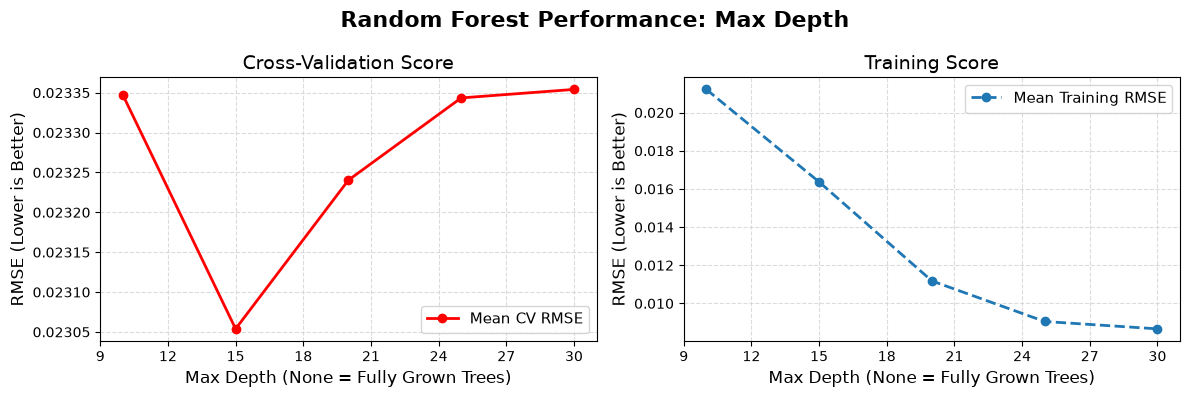

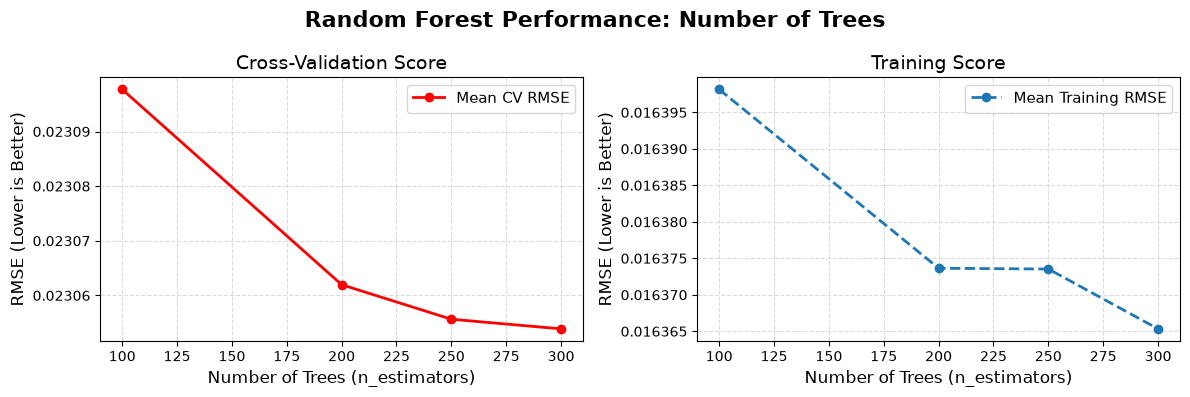

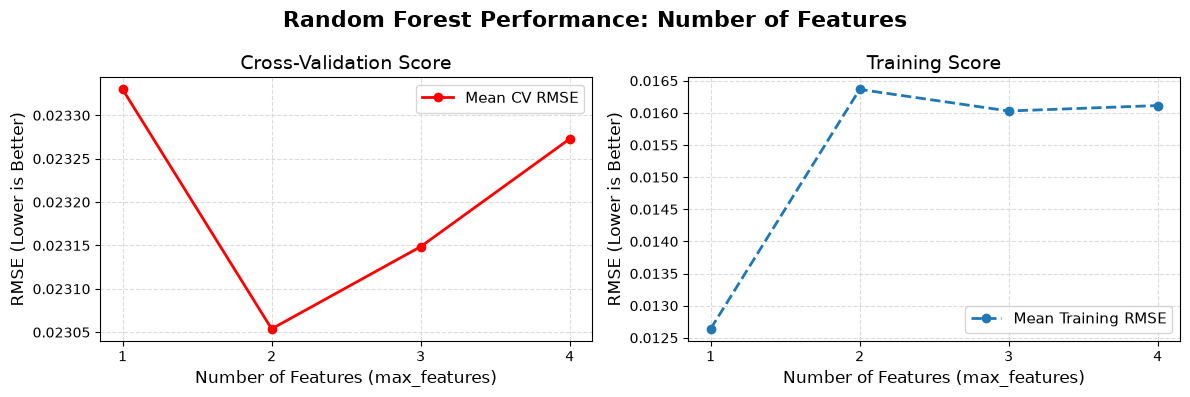

In [4]:
# Plot RMSE vs. Depth
utils.plot_side_by_side_diagnostics(
    search=rf_search, 
    param_name='max_depth', 
    suptitle='Random Forest Performance: Max Depth',
    xlabel_text='Max Depth (None = Fully Grown Trees)'
)

# Plot RMSE vs. Number of Trees
utils.plot_side_by_side_diagnostics(
    search=rf_search, 
    param_name='n_estimators', 
    suptitle='Random Forest Performance: Number of Trees',
    xlabel_text='Number of Trees (n_estimators)'
)

# Plots RMSE vs. Number of Features
utils.plot_side_by_side_diagnostics(
    search=rf_search, 
    param_name='max_features', 
    suptitle='Random Forest Performance: Number of Features',
    xlabel_text='Number of Features (max_features)'
)

In [5]:
# Train a new model with the optimial hyperparameters on the full training set
rf_final = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
rf_final.fit(X_train, y_train)

# Make predictions on the validation set
z_pred_val = rf_final.predict(X_val)

# Calculate and print the metrics
print( "-" * 4, f"Validation Dataset Metrics", "-" * 4)
print(f"Outlier Fraction: {utils.outlier_fraction(z_pred_val, y_val):.16f}")
print(f"Bias:             {utils.bias(z_pred_val, y_val):.16f}")
print(f"NMAD:             {utils.nmad(z_pred_val, y_val):.16f}")
print("-" * 36)

---- Validation Dataset Metrics ----
Outlier Fraction: 0.0247620201286050
Bias:             0.0004832012320641
NMAD:             0.0162753571232854
------------------------------------


In [6]:
# TESTING THE FINAL MODEL
print("=" * 36)
print("FINAL TEST SET EVALUATION")
print(f"Using Hyperparameters: \n{best_params}")
print("=" * 36 + "\n")

# Combine train and val data since we don't need the val
X_train_combined = np.vstack((X_train, X_val))
y_train_combined = np.concatenate((y_train, y_val))

# Train the final model on the now bigger training set
rf_final.fit(np.array(X_train_combined), np.array(y_train_combined)) 

# Make predictions on the test set
z_pred_test = rf_final.predict(np.array(X_test))

# Calculate and print the final metrics
print( "-" * 7, f"Test Dataset Metrics", "-" * 7)
print(f"Outlier Fraction: {utils.outlier_fraction(z_pred_test, y_test):.16f}")
print(f"Bias:             {utils.bias(z_pred_test, y_test):.16f}")
print(f"NMAD:             {utils.nmad(z_pred_test, y_test):.16f}")
print("-" * 36)

FINAL TEST SET EVALUATION
Using Hyperparameters: 
{'max_depth': 15, 'max_features': 2, 'n_estimators': 300}

------- Test Dataset Metrics -------
Outlier Fraction: 0.0234595816845676
Bias:             0.0004393471826929
NMAD:             0.0160631057703104
------------------------------------
